# API Tryouts Notebook

This notebook is a beginner-friendly API playground built around dataframes.

It now imports the reusable package functions from `backend/soc_api` instead of rebuilding the API request and dataframe-conversion logic inside the notebook.

It keeps only the core dataframe set:
- `dataset_info_df`
- `dataset_groups_df`
- `super_classes_df`
- `asset_classes_df`
- `currencies_df`
- `available_asset_fields_df`
- `default_asset_fields_df`
- `full_assets_df`
- `full_asset_correlations_df`
- `full_asset_covariance_df`
- `full_subclass_correlations_df`

The analysis sections at the bottom avoid sorting and focus on:
- shape
- full dataframe display
- missing values
- summary statistics
- selected slices
- simple plots

Step 6 is the main interpretation guide. It is organized by the dataframes those terms belong to, and it separates `verified` meanings from `inferred` ones.


## Step 1: Import the Project Package

Run this first.

This cell finds the repo root, adds `src/` to Python's import path, and then runs `from soc_api import *` so the package's exported functions are available directly in the notebook.

Authentication is handled inside the package through your `.env` file.


In [1]:
import sys
from pathlib import Path

import pandas as pd


def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "src" / "soc_api" / "__init__.py").exists():
            return candidate
    raise RuntimeError("Could not find the project root. Start the notebook from somewhere inside this repo.")


PROJECT_ROOT = find_project_root(Path.cwd())
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from soc_api import *

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)

print("PROJECT_ROOT =", PROJECT_ROOT)


PROJECT_ROOT = n:\Other computers\My Laptop (1)\Ron's Work\Grown up life (sighs)\UWI\Courses\Third Year\Second Semester\SOC exp


## Step 2: The Main Dataframe Functions Used Here

These are the main package functions this notebook uses after `from soc_api import *`.

They are re-exported by `backend/soc_api/__init__.py`.


In [2]:
dataframe_api_functions_df = pd.DataFrame(
    [
        {
            "function_name": "get_info_frames()",
            "main_return": "dict[str, pd.DataFrame]",
            "what_it_loads": "small metadata tables from /api/soc/info/",
        },
        {
            "function_name": "get_full_assets_df()",
            "main_return": "pd.DataFrame",
            "what_it_loads": "the complete asset table",
        },
        {
            "function_name": "get_asset_correlations_df()",
            "main_return": "pd.DataFrame",
            "what_it_loads": "the asset correlation matrix",
        },
        {
            "function_name": "get_asset_covariance_df()",
            "main_return": "pd.DataFrame",
            "what_it_loads": "the asset covariance matrix",
        },
        {
            "function_name": "get_subclass_correlations_df()",
            "main_return": "pd.DataFrame",
            "what_it_loads": "the subclass correlation matrix",
        },
    ]
)

dataframe_api_functions_df


,function_name,main_return,what_it_loads
0,get_info_frames(),"dict[str, pd.DataFrame]",small metadata tables from /api/soc/info/
1,get_full_assets_df(),pd.DataFrame,the complete asset table
2,get_asset_correlations_df(),pd.DataFrame,the asset correlation matrix
3,get_asset_covariance_df(),pd.DataFrame,the asset covariance matrix
4,get_subclass_correlations_df(),pd.DataFrame,the subclass correlation matrix


## Step 3: Load the Info Endpoint Dataframes

This cell calls `get_info_frames()` from the project package.

The function returns a dictionary of small metadata tables about the challenge dataset.


In [3]:
info_frames = get_info_frames()

dataset_info_df = info_frames["dataset_info_df"]
dataset_groups_df = info_frames["dataset_groups_df"]
super_classes_df = info_frames["super_classes_df"]
asset_classes_df = info_frames["asset_classes_df"]
currencies_df = info_frames["currencies_df"]
available_asset_fields_df = info_frames["available_asset_fields_df"]
default_asset_fields_df = info_frames["default_asset_fields_df"]

INFO_DATAFRAME_NAMES = list(info_frames.keys())
print("INFO_DATAFRAME_NAMES =", INFO_DATAFRAME_NAMES)

dataset_info_df


INFO_DATAFRAME_NAMES = ['dataset_info_df', 'dataset_groups_df', 'super_classes_df', 'asset_classes_df', 'currencies_df', 'available_asset_fields_df', 'default_asset_fields_df']


,asset_count,correlation_pair_count,covariance_pair_count,subclass_pair_count
0,25,625,625,144


## Step 3A: Inspect Each Info Dataframe Individually

Run the next cells one by one if you want to learn the names and see exactly what each small dataframe contains.

Each cell prints the shape and then displays the full dataframe.


In [4]:
print("dataset_info_df.shape =", dataset_info_df.shape)
dataset_info_df


dataset_info_df.shape = (1, 4)


,asset_count,correlation_pair_count,covariance_pair_count,subclass_pair_count
0,25,625,625,144


In [5]:
print("dataset_groups_df.shape =", dataset_groups_df.shape)
dataset_groups_df


dataset_groups_df.shape = (4, 4)


,id,name,description,row_count
0,assets,Asset Fundamentals,"Asset universe with return, risk, and exposure...",25
1,asset_correlations,Asset Correlation Matrix,Pairwise asset correlations used to model port...,625
2,asset_covariance,Asset Covariance Matrix,Pairwise covariance values for variance and vo...,625
3,subclass_correlations,Subclass Correlation Matrix,Correlation relationships between challenge as...,144


In [6]:
print("super_classes_df.shape =", super_classes_df.shape)
super_classes_df


super_classes_df.shape = (4, 1)


,super_class
0,Cash
1,Equity
2,Fixed Income
3,Fund


In [7]:
print("asset_classes_df.shape =", asset_classes_df.shape)
asset_classes_df


asset_classes_df.shape = (12, 1)


,asset_class
0,Alternative Investments
1,Corporate Bonds
2,Domestic Cyclical Equity
3,Domestic Defensive Equity
4,Domestic Financial Equity
5,Emerging Market Equity
6,Global Tech Equity
7,JMD T-Bill
8,Long Government Bonds
9,Real Estate Fund


In [8]:
print("currencies_df.shape =", currencies_df.shape)
currencies_df


currencies_df.shape = (3, 1)


,currency
0,JMD
1,"JMD,USD"
2,USD


In [9]:
print("available_asset_fields_df.shape =", available_asset_fields_df.shape)
available_asset_fields_df


available_asset_fields_df.shape = (15, 1)


,field_name
0,ticker
1,super_class
2,asset_class
3,currency
4,total_expected_return
5,income_yield_ann
6,volatility_ann
7,semi_deviation_ann
8,skewness
9,excess_kurtosis


In [10]:
print("default_asset_fields_df.shape =", default_asset_fields_df.shape)
default_asset_fields_df


default_asset_fields_df.shape = (10, 1)


,field_name
0,ticker
1,super_class
2,asset_class
3,currency
4,total_expected_return
5,volatility_ann
6,income_yield_ann
7,rate_beta
8,inflation_beta
9,fx_beta


## Step 4: Load the 4 Complete Challenge Dataframes

These are the main tables you said you want to analyze.

This cell calls the four main dataframe functions from `soc_api.frames`.


In [11]:
full_assets_df = get_full_assets_df()
full_asset_correlations_df = get_asset_correlations_df()
full_asset_covariance_df = get_asset_covariance_df()
full_subclass_correlations_df = get_subclass_correlations_df()

COMPLETE_DATAFRAMES = {
    "full_assets_df": full_assets_df,
    "full_asset_correlations_df": full_asset_correlations_df,
    "full_asset_covariance_df": full_asset_covariance_df,
    "full_subclass_correlations_df": full_subclass_correlations_df,
}
COMPLETE_DATAFRAME_NAMES = list(COMPLETE_DATAFRAMES.keys())

COMPLETE_DATAFRAME_NAMES


['full_assets_df',
 'full_asset_correlations_df',
 'full_asset_covariance_df',
 'full_subclass_correlations_df']

## Step 5: Keep a Handy Catalog of All Dataframes

Use this whenever you want a quick reminder of what is loaded.

The catalog itself is built with the package function `build_dataframe_catalog_df()`.


In [12]:
DATAFRAMES = {
    "dataset_info_df": dataset_info_df,
    "dataset_groups_df": dataset_groups_df,
    "super_classes_df": super_classes_df,
    "asset_classes_df": asset_classes_df,
    "currencies_df": currencies_df,
    "available_asset_fields_df": available_asset_fields_df,
    "default_asset_fields_df": default_asset_fields_df,
    "full_assets_df": full_assets_df,
    "full_asset_correlations_df": full_asset_correlations_df,
    "full_asset_covariance_df": full_asset_covariance_df,
    "full_subclass_correlations_df": full_subclass_correlations_df,
}
DATAFRAME_NAMES = list(DATAFRAMES.keys())

dataframe_catalog_df = build_dataframe_catalog_df()
dataframe_catalog_df


,dataframe_name,source_endpoint,description
0,dataset_info_df,/api/soc/info/,One-row summary of counts from the info endpoint
1,dataset_groups_df,/api/soc/info/,List of dataset groups available in the challenge
2,super_classes_df,/api/soc/info/,"List of super classes such as Cash, Equity, Fund"
3,asset_classes_df,/api/soc/info/,List of asset classes
4,currencies_df,/api/soc/info/,List of currencies found in the dataset
5,available_asset_fields_df,/api/soc/info/,Fields you are allowed to request from the ass...
6,default_asset_fields_df,/api/soc/info/,Default fields returned by the assets endpoint
7,full_assets_df,/api/soc/assets/,Complete assets table with all allowed asset f...
8,full_asset_correlations_df,/api/soc/correlations/assets/,Complete 25x25 asset correlation matrix
9,full_asset_covariance_df,/api/soc/covariance/assets/,Complete 25x25 asset covariance matrix


## Step 6: Source-Backed Interpretation Guide

This guide is organized by the dataframes the terms belong to.

### Verification review of the earlier guide
- The earlier explanations for `asset_class`, `currency`, `total_expected_return`, `income_yield_ann`, `volatility_ann`, `correlation`, and `covariance` were directionally correct.
- They were too rough because they did not explain how to read the numbers or how strongly the meaning was supported by sources.
- `semi_deviation_ann`, `rate_beta`, `inflation_beta`, and `fx_beta` remain `inferred` because the local project material does not define the exact formula.

### `full_assets_df`

This is the one-row-per-asset table. The main terms here are about what the asset is, what return is being estimated, how risky the asset seems, and how sensitive it may be to broader economic factors.

| Term | Plain-English meaning | How to read the values | Status |
| --- | --- | --- | --- |
| `ticker` | Short market symbol for an asset | Identifier only; not a measurement | verified |
| `super_class` | Broad grouping such as Equity or Fixed Income | Good for high-level grouping | verified |
| `asset_class` | More specific category inside the broad grouping | Good for more detailed grouping | verified |
| `currency` | Money unit used for the asset | `USD` and `JMD` are currencies, not risk levels | verified |
| `total_expected_return` | Estimated total return over a year | Model estimate; not a promise | verified |
| `income_yield_ann` | Income-related yield over one year | Higher values mean more expected income contribution | verified |
| `volatility_ann` | Annualized variability of returns | Higher values usually mean wider swings and more uncertainty | verified |
| `semi_deviation_ann` | Downside-focused version of volatility | Focuses more on downside moves than upside moves | inferred |
| `skewness` | Asymmetry of the return distribution | Sign shows which side has the longer tail | verified |
| `excess_kurtosis` | Tail-heaviness relative to a normal distribution | Larger values suggest more extreme outcomes | verified |
| `modified_duration` | Bond sensitivity to interest-rate changes | Larger values usually mean more rate sensitivity | verified |
| `rate_beta` | Sensitivity score for rate moves | Read as an interest-rate sensitivity indicator unless the project gives a formula later | inferred |
| `inflation_beta` | Sensitivity score for inflation changes | Read as an inflation sensitivity indicator | inferred |
| `fx_beta` | Sensitivity score for foreign-exchange moves | Read as a currency sensitivity indicator | inferred |
| `expense_ratio_ann` | Annual cost ratio charged by a fund-like product | Higher values mean more annual cost drag | verified |

### `full_asset_correlations_df`

This is the full asset correlation matrix.

How to read the numbers:
- `1` means two assets move perfectly together on the correlation scale
- `-1` means they move in opposite directions on that scale
- `0` means little linear relationship
- the diagonal is always `1` because each asset is perfectly correlated with itself
- the matrix is symmetric, so A-vs-B should match B-vs-A

Why this table is useful:
- correlation is standardized, so it is easier to compare relationships across different pairs
- low or negative correlation can matter for diversification

### `full_asset_covariance_df`

This is the full asset covariance matrix.

Covariance needs more care than correlation because the values are not standardized.

How to read the numbers exactly:
- a positive covariance means the two assets tend to be above or below their own averages at the same time
- a negative covariance means when one asset is above its own average, the other tends to be below its own average
- a covariance near `0` means little linear co-movement around their averages
- the diagonal cells are each asset's variance, so they describe that asset's own spread
- the off-diagonal cells describe joint movement between different assets

What the size of the number means:
- bigger absolute values can indicate stronger co-movement
- but covariance also depends on the scale and volatility of the underlying series
- because of that, raw covariance magnitudes are harder to compare than correlations
- two volatile assets can have a larger covariance even if their relationship is not more tightly linked in a standardized sense

Practical rule:
- use covariance when you want the raw-scale co-movement information
- use correlation when you want an easier strength comparison on a common scale

### `full_subclass_correlations_df`

This is the correlation matrix at the asset-subclass level rather than the single-asset level.

You read the numbers the same way you read `full_asset_correlations_df`, but the units being compared are broader groups instead of individual tickers.

### General terms

| Term | Meaning |
| --- | --- |
| `asset` | One investable item in the dataset |
| `metadata` | Data about the dataset itself, such as counts and available fields |
| `API` | The online service you ask for data |
| `authentication` | Proving you are allowed to use the API, usually with an API key |
| `histogram` | Plot that groups numeric values into bins so you can see the distribution |
| `heatmap-style matrix plot` | Color-coded matrix view used to scan high and low values quickly |

### Source notes and current gaps
- `super_class` and `asset_class` come from the API's own grouping structure and the local Dimension Depths SOC documentation.
- `semi_deviation_ann`, `rate_beta`, `inflation_beta`, and `fx_beta` are still the least certain items because no project-specific formula is currently documented in this repo.
- For the exact external references, use the source list in `README.md` and the `source_basis` column in `column_guide_df` below.


In [13]:
column_guide_df = pd.DataFrame(
    [
        {
            "related_dataframe": "full_assets_df",
            "term_name": "ticker",
            "plain_english_meaning": "Short market symbol for an asset.",
            "how_to_read_values": "Identifier only; not a measurement.",
            "verification_status": "verified",
            "source_basis": "Investor.gov stock symbol glossary",
        },
        {
            "related_dataframe": "full_assets_df",
            "term_name": "super_class",
            "plain_english_meaning": "Broad API grouping such as Equity or Fixed Income.",
            "how_to_read_values": "Use for high-level grouping.",
            "verification_status": "verified",
            "source_basis": "Dimension Depths dataset grouping plus /api/soc/info/",
        },
        {
            "related_dataframe": "full_assets_df",
            "term_name": "asset_class",
            "plain_english_meaning": "More specific category inside the broad grouping.",
            "how_to_read_values": "Use for more detailed grouping.",
            "verification_status": "verified",
            "source_basis": "Dimension Depths dataset grouping plus /api/soc/info/",
        },
        {
            "related_dataframe": "full_assets_df",
            "term_name": "currency",
            "plain_english_meaning": "Money unit the asset is measured in.",
            "how_to_read_values": "Currency label, not a risk score.",
            "verification_status": "verified",
            "source_basis": "Dataset field meaning",
        },
        {
            "related_dataframe": "full_assets_df",
            "term_name": "total_expected_return",
            "plain_english_meaning": "Estimated total return over a year.",
            "how_to_read_values": "Treat as a model estimate, not a guarantee.",
            "verification_status": "verified",
            "source_basis": "Return terminology plus dataset field name",
        },
        {
            "related_dataframe": "full_assets_df",
            "term_name": "income_yield_ann",
            "plain_english_meaning": "Income-related yield expected over one year.",
            "how_to_read_values": "Higher values mean more expected income contribution.",
            "verification_status": "verified",
            "source_basis": "Investor.gov yield glossary plus dataset field name",
        },
        {
            "related_dataframe": "full_assets_df",
            "term_name": "volatility_ann",
            "plain_english_meaning": "Annualized measure of how much returns move around.",
            "how_to_read_values": "Higher values usually mean wider swings and more uncertainty.",
            "verification_status": "verified",
            "source_basis": "Investor.gov risk explainer",
        },
        {
            "related_dataframe": "full_assets_df",
            "term_name": "semi_deviation_ann",
            "plain_english_meaning": "Downside-focused version of volatility.",
            "how_to_read_values": "Focuses more on bad downside moves than upside moves.",
            "verification_status": "inferred",
            "source_basis": "Standard finance usage of semi-deviation; no project-specific formula found",
        },
        {
            "related_dataframe": "full_assets_df",
            "term_name": "skewness",
            "plain_english_meaning": "Asymmetry of the return distribution.",
            "how_to_read_values": "Sign shows which side has the longer tail.",
            "verification_status": "verified",
            "source_basis": "NIST skewness reference",
        },
        {
            "related_dataframe": "full_assets_df",
            "term_name": "excess_kurtosis",
            "plain_english_meaning": "Tail-heaviness relative to a normal distribution.",
            "how_to_read_values": "Larger values suggest more extreme outcomes.",
            "verification_status": "verified",
            "source_basis": "NIST kurtosis reference",
        },
        {
            "related_dataframe": "full_assets_df",
            "term_name": "modified_duration",
            "plain_english_meaning": "Bond sensitivity to interest-rate changes.",
            "how_to_read_values": "Larger values usually mean more rate sensitivity.",
            "verification_status": "verified",
            "source_basis": "Investor.gov modified duration glossary",
        },
        {
            "related_dataframe": "full_assets_df",
            "term_name": "rate_beta",
            "plain_english_meaning": "Sensitivity score for interest-rate moves.",
            "how_to_read_values": "Read as an interest-rate sensitivity indicator unless a formula is documented later.",
            "verification_status": "inferred",
            "source_basis": "Beta naming convention plus the dataset field name",
        },
        {
            "related_dataframe": "full_assets_df",
            "term_name": "inflation_beta",
            "plain_english_meaning": "Sensitivity score for inflation changes.",
            "how_to_read_values": "Read as an inflation sensitivity indicator.",
            "verification_status": "inferred",
            "source_basis": "Beta naming convention plus FRED inflation explainer and the dataset field name",
        },
        {
            "related_dataframe": "full_assets_df",
            "term_name": "fx_beta",
            "plain_english_meaning": "Sensitivity score for foreign-exchange or currency moves.",
            "how_to_read_values": "Read as a currency sensitivity indicator.",
            "verification_status": "inferred",
            "source_basis": "Beta naming convention plus the dataset field name",
        },
        {
            "related_dataframe": "full_assets_df",
            "term_name": "expense_ratio_ann",
            "plain_english_meaning": "Annual operating-cost ratio charged by a fund-like product.",
            "how_to_read_values": "Higher values mean more annual cost drag.",
            "verification_status": "verified",
            "source_basis": "Investor.gov expense ratio glossary",
        },
        {
            "related_dataframe": "full_asset_correlations_df",
            "term_name": "correlation",
            "plain_english_meaning": "Standardized measure of how similarly two assets move.",
            "how_to_read_values": "Near 1 means together, near -1 means opposite, near 0 means little linear relationship.",
            "verification_status": "verified",
            "source_basis": "pandas correlation docs plus standard statistics meaning",
        },
        {
            "related_dataframe": "full_asset_correlations_df",
            "term_name": "correlation matrix",
            "plain_english_meaning": "Table of pairwise correlations for every asset against every other asset.",
            "how_to_read_values": "Diagonal is 1 and the matrix should be symmetric.",
            "verification_status": "verified",
            "source_basis": "pandas correlation docs plus standard matrix interpretation",
        },
        {
            "related_dataframe": "full_asset_covariance_df",
            "term_name": "covariance",
            "plain_english_meaning": "Raw-scale measure of how two assets move together.",
            "how_to_read_values": "Positive means same-direction movement around averages, negative means opposite-direction movement, near 0 means little linear co-movement.",
            "verification_status": "verified",
            "source_basis": "pandas covariance docs plus NumPy covariance docs",
        },
        {
            "related_dataframe": "full_asset_covariance_df",
            "term_name": "covariance matrix",
            "plain_english_meaning": "Table of pairwise covariances for every asset against every other asset.",
            "how_to_read_values": "Diagonal entries are variances; off-diagonal entries describe joint movement between different assets.",
            "verification_status": "verified",
            "source_basis": "NumPy covariance docs plus standard matrix interpretation",
        },
        {
            "related_dataframe": "full_subclass_correlations_df",
            "term_name": "subclass correlation matrix",
            "plain_english_meaning": "Correlation matrix for broader asset subclasses rather than single assets.",
            "how_to_read_values": "Interpret the numbers the same way as asset correlation, but at the group level.",
            "verification_status": "verified",
            "source_basis": "Correlation interpretation plus dataset grouping structure",
        },
        {
            "related_dataframe": "general",
            "term_name": "histogram",
            "plain_english_meaning": "Plot that groups values into bins so you can see the distribution.",
            "how_to_read_values": "Use it to see spread, clustering, and rough shape.",
            "verification_status": "verified",
            "source_basis": "Matplotlib hist docs",
        },
        {
            "related_dataframe": "general",
            "term_name": "heatmap-style matrix plot",
            "plain_english_meaning": "Color-coded matrix view used to scan high and low values quickly.",
            "how_to_read_values": "Use color differences to spot stronger and weaker regions of the matrix.",
            "verification_status": "verified",
            "source_basis": "Matplotlib imshow docs",
        },
    ]
)

column_guide_df


,related_dataframe,term_name,plain_english_meaning,how_to_read_values,verification_status,source_basis
0,full_assets_df,ticker,Short market symbol for an asset.,Identifier only; not a measurement.,verified,Investor.gov stock symbol glossary
1,full_assets_df,super_class,Broad API grouping such as Equity or Fixed Inc...,Use for high-level grouping.,verified,Dimension Depths dataset grouping plus /api/so...
2,full_assets_df,asset_class,More specific category inside the broad grouping.,Use for more detailed grouping.,verified,Dimension Depths dataset grouping plus /api/so...
3,full_assets_df,currency,Money unit the asset is measured in.,"Currency label, not a risk score.",verified,Dataset field meaning
4,full_assets_df,total_expected_return,Estimated total return over a year.,"Treat as a model estimate, not a guarantee.",verified,Return terminology plus dataset field name
5,full_assets_df,income_yield_ann,Income-related yield expected over one year.,Higher values mean more expected income contri...,verified,Investor.gov yield glossary plus dataset field...
6,full_assets_df,volatility_ann,Annualized measure of how much returns move ar...,Higher values usually mean wider swings and mo...,verified,Investor.gov risk explainer
7,full_assets_df,semi_deviation_ann,Downside-focused version of volatility.,Focuses more on bad downside moves than upside...,inferred,Standard finance usage of semi-deviation; no p...
8,full_assets_df,skewness,Asymmetry of the return distribution.,Sign shows which side has the longer tail.,verified,NIST skewness reference
9,full_assets_df,excess_kurtosis,Tail-heaviness relative to a normal distribution.,Larger values suggest more extreme outcomes.,verified,NIST kurtosis reference


## Step 7: Worked Examples

This section shows one example asset row and one example covariance pair using live values from the current dataset.

The chosen examples are:
- asset row: `CWPU`
- covariance pair: `CWPU` and `DTOT`

If the API data changes in the future, rerun these cells and the values will update automatically.


In [14]:
example_asset_ticker = 'CWPU'
example_asset_df = full_assets_df.loc[[example_asset_ticker]].T
example_asset_df.columns = [example_asset_ticker]
example_asset_df


,CWPU
super_class,Fixed Income
asset_class,Short Government Bonds
currency,JMD
total_expected_return,0.0584
income_yield_ann,0.0584
volatility_ann,0.0239
semi_deviation_ann,0.0159
skewness,0.1301
excess_kurtosis,0.3887
modified_duration,1.2713


### How to read the `CWPU` example

Use this row like a structured profile of one asset.

- `super_class = Fixed Income` and `asset_class = Short Government Bonds` tell you this is a bond-like fixed-income asset, not an equity.
- `currency = JMD` tells you the row is expressed in Jamaican dollars.
- `total_expected_return` and `income_yield_ann` are the same in this row, so the expected return is being driven almost entirely by income rather than price appreciation.
- `volatility_ann` and `semi_deviation_ann` are both fairly low in this dataset, which is consistent with a lower-volatility fixed-income profile.
- `modified_duration` is positive, so the asset still has some interest-rate sensitivity.
- `fx_beta = 0.0` means this field is not showing currency sensitivity for this example.

That combination makes `CWPU` a useful example of how the asset table mixes category labels, return estimates, risk measures, and sensitivity measures in one row.


In [15]:
example_covariance_pair = ('CWPU', 'DTOT')
asset_a, asset_b = example_covariance_pair

example_covariance_summary_df = pd.DataFrame(
    [
        {'metric': f'covariance_{asset_a}_{asset_b}', 'value': full_asset_covariance_df.loc[asset_a, asset_b]},
        {'metric': f'correlation_{asset_a}_{asset_b}', 'value': full_asset_correlations_df.loc[asset_a, asset_b]},
        {'metric': f'variance_{asset_a}', 'value': full_asset_covariance_df.loc[asset_a, asset_a]},
        {'metric': f'variance_{asset_b}', 'value': full_asset_covariance_df.loc[asset_b, asset_b]},
    ]
)

example_covariance_summary_df


,metric,value
0,covariance_CWPU_DTOT,0.001776
1,correlation_CWPU_DTOT,0.632400
2,variance_CWPU,0.000571
3,variance_DTOT,0.013806


### How to read the `CWPU` / `DTOT` covariance example

This example is useful because both assets are fixed-income assets, but they do not move identically.

- The covariance is positive, so the two assets tend to move in the same direction around their own averages.
- The correlation is also positive, which supports the same-direction interpretation on a standardized scale.
- The diagonal values are the variances of `CWPU` and `DTOT`, so they tell you how spread out each asset is by itself.
- `DTOT` has the much larger variance in this pair, so part of the off-diagonal covariance size is coming from scale, not just from relationship strength.
- That is the main reason covariance needs more care than correlation: a bigger raw covariance does not automatically mean a tighter relationship.

This is the practical reading rule:
- covariance tells you raw co-movement
- correlation tells you easier-to-compare relationship strength


## Step 8: Analysis Workspace Setup

Run this once before the plots.


In [16]:
from IPython.core.getipython import get_ipython

ipython = get_ipython()
if ipython is not None:
    ipython.run_line_magic('matplotlib', 'inline')

import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.grid'] = True
            


In [17]:
COMPLETE_DATAFRAME_NAMES


['full_assets_df',
 'full_asset_correlations_df',
 'full_asset_covariance_df',
 'full_subclass_correlations_df']

In [18]:
dataframe_catalog_df


,dataframe_name,source_endpoint,description
0,dataset_info_df,/api/soc/info/,One-row summary of counts from the info endpoint
1,dataset_groups_df,/api/soc/info/,List of dataset groups available in the challenge
2,super_classes_df,/api/soc/info/,"List of super classes such as Cash, Equity, Fund"
3,asset_classes_df,/api/soc/info/,List of asset classes
4,currencies_df,/api/soc/info/,List of currencies found in the dataset
5,available_asset_fields_df,/api/soc/info/,Fields you are allowed to request from the ass...
6,default_asset_fields_df,/api/soc/info/,Default fields returned by the assets endpoint
7,full_assets_df,/api/soc/assets/,Complete assets table with all allowed asset f...
8,full_asset_correlations_df,/api/soc/correlations/assets/,Complete 25x25 asset correlation matrix
9,full_asset_covariance_df,/api/soc/covariance/assets/,Complete 25x25 asset covariance matrix


## Step 9: Analyze `full_assets_df`

This omnibus notebook keeps the quick dataframe verification work here so the focused analysis notebooks can stay lean.

Use this section for checks like:
- `.shape`
- viewing the dataframe directly
- `.dtypes`
- missing-value checks
- simple group counts
- `.describe()` summaries

How to read it:
- each row is one asset
- each column is one field about that asset


In [19]:
full_assets_df.shape


(25, 14)

In [20]:
full_assets_df


,super_class,asset_class,currency,total_expected_return,income_yield_ann,volatility_ann,semi_deviation_ann,skewness,excess_kurtosis,modified_duration,rate_beta,inflation_beta,fx_beta,expense_ratio_ann
ticker,,,,,,,,,,,,,,
BQB,Equity,Emerging Market Equity,USD,0.1553,0.0000,0.2073,0.2024,-0.3350,3.9012,0.0000,-1.3682,0.2242,1.0586,0.0000
CQOAC,Equity,Emerging Market Equity,USD,0.1593,0.0000,0.2299,0.2059,-0.4310,3.8945,0.0000,-1.2466,0.1881,1.0167,0.0000
CWPU,Fixed Income,Short Government Bonds,JMD,0.0584,0.0584,0.0239,0.0159,0.1301,0.3887,1.2713,-1.1713,-0.4573,0.0000,0.0000
DTOT,Fixed Income,Corporate Bonds,JMD,0.0938,0.0938,0.1175,0.0855,-0.3954,1.2269,5.8494,-4.2453,-0.8710,0.0000,0.0000
EMWB,Equity,Emerging Market Equity,USD,0.1171,0.0000,0.2609,0.2233,-0.9292,2.1682,0.0000,-1.9272,0.4109,1.1412,0.0000
GGOC,Equity,Domestic Defensive Equity,JMD,0.1017,0.0493,0.1515,0.1436,-0.3878,1.0373,0.0000,-1.6398,0.0635,0.0000,0.0000
IGRIG,Fund,Alternative Investments,"JMD,USD",0.1182,0.0252,0.1364,0.1014,-0.0985,1.4272,2.7163,-1.8297,0.4029,0.2081,0.0177
IRKXL,Fixed Income,Corporate Bonds,JMD,0.0967,0.0967,0.0875,0.0816,-0.2455,2.3551,4.0332,-4.9758,-0.8868,0.0000,0.0000
IZQLN,Equity,Domestic Cyclical Equity,JMD,0.1379,0.0107,0.1809,0.1670,-0.7724,1.5611,0.0000,0.0555,0.2845,0.0000,0.0000


In [21]:
full_assets_df.dtypes


super_class                  str
asset_class                  str
currency                     str
total_expected_return    float64
income_yield_ann         float64
volatility_ann           float64
semi_deviation_ann       float64
skewness                 float64
excess_kurtosis          float64
modified_duration        float64
rate_beta                float64
inflation_beta           float64
fx_beta                  float64
expense_ratio_ann        float64
dtype: object

In [22]:
full_assets_df.isna().sum()


super_class              0
asset_class              0
currency                 0
total_expected_return    0
income_yield_ann         0
volatility_ann           0
semi_deviation_ann       0
skewness                 0
excess_kurtosis          0
modified_duration        0
rate_beta                0
inflation_beta           0
fx_beta                  0
expense_ratio_ann        0
dtype: int64

In [23]:
full_assets_df.groupby('asset_class').size()


asset_class
Alternative Investments      1
Corporate Bonds              2
Domestic Cyclical Equity     3
Domestic Defensive Equity    3
Domestic Financial Equity    3
Emerging Market Equity       3
Global Tech Equity           3
JMD T-Bill                   1
Long Government Bonds        2
Real Estate Fund             1
Short Government Bonds       2
USD T-Bill                   1
dtype: int64

In [24]:
full_assets_df[['total_expected_return', 'income_yield_ann', 'volatility_ann']].describe()


,total_expected_return,income_yield_ann,volatility_ann
count,25.000000,25.000000,25.000000
mean,0.110828,0.034248,0.157888
std,0.034889,0.033732,0.081694
min,0.039400,0.000000,0.007100
25%,0.093800,0.000000,0.116500
50%,0.117100,0.025200,0.174500
75%,0.131100,0.058400,0.207300
max,0.176500,0.096700,0.287600


### Plots for `full_assets_df`

These plots are simple distribution checks.
A histogram groups values into bins so you can see how spread out the values are.
The bar chart compares average volatility across broad asset groups.


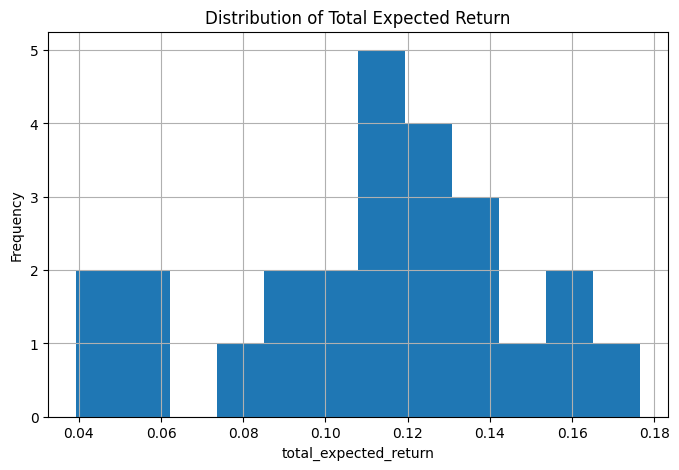

In [25]:
full_assets_df['total_expected_return'].plot(kind='hist', bins=12, title='Distribution of Total Expected Return')
plt.xlabel('total_expected_return')
plt.show()


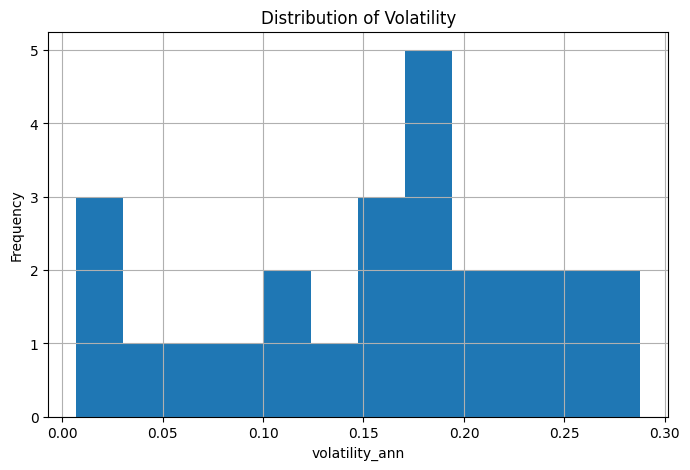

In [26]:
full_assets_df['volatility_ann'].plot(kind='hist', bins=12, title='Distribution of Volatility')
plt.xlabel('volatility_ann')
plt.show()


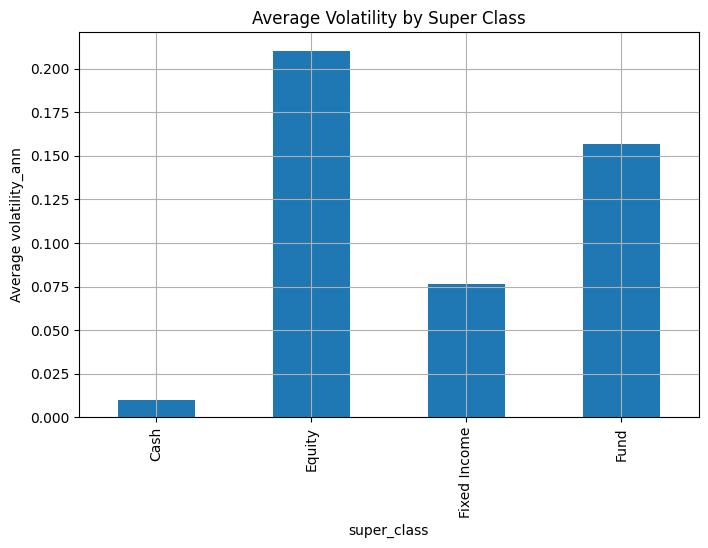

In [27]:
full_assets_df.groupby('super_class')['volatility_ann'].mean().plot(kind='bar', title='Average Volatility by Super Class')
plt.ylabel('Average volatility_ann')
plt.show()


In [28]:
# Try your own full_assets_df analysis below.
# Example ideas:
# full_assets_df[full_assets_df['currency'] == 'USD']
# full_assets_df[['rate_beta', 'inflation_beta', 'fx_beta']].describe()


## Step 10: Analyze `full_asset_correlations_df`

This is the full asset correlation matrix.

How to read it:
- the same asset list appears on rows and columns
- each cell compares one asset with another
- values near `1` mean the pair tends to move together
- values near `-1` mean the pair tends to move in opposite directions
- values near `0` mean little linear relationship
- the diagonal is always `1`

Use the correlation section in Step 6 if you want the standardized-relationship interpretation in one place.


In [29]:
full_asset_correlations_df.shape


(25, 25)

In [30]:
full_asset_correlations_df


,BQB,CQOAC,CWPU,DTOT,EMWB,GGOC,IGRIG,IRKXL,IZQLN,JFG,...,QPESE,RJK,TBILLJMD,TBILLUSD,TIHE,WBG,XEAK,XKFZ,XPMCJ,YTR
BQB,1.000000,0.850117,0.060004,0.236533,0.839306,0.329064,0.449230,0.222556,0.423066,-0.113809,...,-0.105591,0.814053,0.019077,0.208816,0.386537,0.773680,0.355052,0.319879,0.262177,0.416907
CQOAC,0.850117,1.000000,0.075285,0.275946,0.888708,0.288840,0.493810,0.194541,0.470386,-0.099905,...,-0.108553,0.781159,0.050618,0.245420,0.361015,0.770178,0.396663,0.366388,0.315679,0.410182
CWPU,0.060004,0.075285,1.000000,0.632400,0.069077,0.203869,0.546339,0.548577,0.098351,0.671385,...,0.615403,0.074688,0.077146,0.088809,0.122963,0.068448,0.353724,0.102096,0.158274,0.139059
DTOT,0.236533,0.275946,0.632400,1.000000,0.236582,0.210697,0.539964,0.714754,0.264506,0.507490,...,0.515755,0.187222,0.048057,0.072843,0.268137,0.166105,0.311655,0.273799,0.206129,0.330727
EMWB,0.839306,0.888708,0.069077,0.236582,1.000000,0.295978,0.481795,0.224251,0.471834,-0.119272,...,-0.091809,0.782760,0.032211,0.266518,0.411329,0.761326,0.336217,0.424036,0.262441,0.466240
GGOC,0.329064,0.288840,0.203869,0.210697,0.295978,1.000000,0.315123,0.266658,0.406255,-0.119092,...,-0.088574,0.340272,0.072648,-0.049504,0.191029,0.302860,0.385108,0.163459,0.765537,0.340708
IGRIG,0.449230,0.493810,0.546339,0.539964,0.481795,0.315123,1.000000,0.624815,0.505453,0.435676,...,0.399626,0.447491,0.080060,0.159528,0.422967,0.431549,0.590681,0.454833,0.396448,0.469910
IRKXL,0.222556,0.194541,0.548577,0.714754,0.224251,0.266658,0.624815,1.000000,0.279098,0.510088,...,0.548138,0.145804,0.048718,0.050576,0.285226,0.120857,0.328510,0.205250,0.201008,0.362775
IZQLN,0.423066,0.470386,0.098351,0.264506,0.471834,0.406255,0.505453,0.279098,1.000000,-0.281649,...,-0.253224,0.369968,0.065979,0.026017,0.627378,0.433350,0.534165,0.642194,0.376992,0.708137
JFG,-0.113809,-0.099905,0.671385,0.507490,-0.119272,-0.119092,0.435676,0.510088,-0.281649,1.000000,...,0.838946,-0.139083,-0.120259,0.045461,-0.196576,-0.145293,0.161922,-0.279938,-0.089389,-0.331074


In [31]:
full_asset_correlations_df.iloc[:5, :5]


,BQB,CQOAC,CWPU,DTOT,EMWB
BQB,1.000000,0.850117,0.060004,0.236533,0.839306
CQOAC,0.850117,1.000000,0.075285,0.275946,0.888708
CWPU,0.060004,0.075285,1.000000,0.632400,0.069077
DTOT,0.236533,0.275946,0.632400,1.000000,0.236582
EMWB,0.839306,0.888708,0.069077,0.236582,1.000000


In [32]:
selected_assets = ['TBILLJMD', 'TBILLUSD', 'PVAU', 'JFG', 'EMWB']
full_asset_correlations_df.loc[selected_assets, selected_assets]


,TBILLJMD,TBILLUSD,PVAU,JFG,EMWB
TBILLJMD,1.000000,0.199045,0.111981,-0.120259,0.032211
TBILLUSD,0.199045,1.000000,0.069849,0.045461,0.266518
PVAU,0.111981,0.069849,1.000000,0.702427,0.101769
JFG,-0.120259,0.045461,0.702427,1.000000,-0.119272
EMWB,0.032211,0.266518,0.101769,-0.119272,1.000000


In [33]:
correlation_pairs_df = (
    full_asset_correlations_df.stack()
    .reset_index()
    .rename(columns={'level_0': 'asset_1', 'level_1': 'asset_2', 0: 'correlation'})
)
correlation_pairs_df = correlation_pairs_df[correlation_pairs_df['asset_1'] != correlation_pairs_df['asset_2']]
correlation_pairs_df.head()


,asset_1,asset_2,correlation
1,BQB,CQOAC,0.850117
2,BQB,CWPU,0.060004
3,BQB,DTOT,0.236533
4,BQB,EMWB,0.839306
5,BQB,GGOC,0.329064


### Plots for `full_asset_correlations_df`

The histogram shows the distribution of pairwise correlations.
The color plot below is a heatmap-style matrix: color helps you see clusters of high or low correlation quickly.


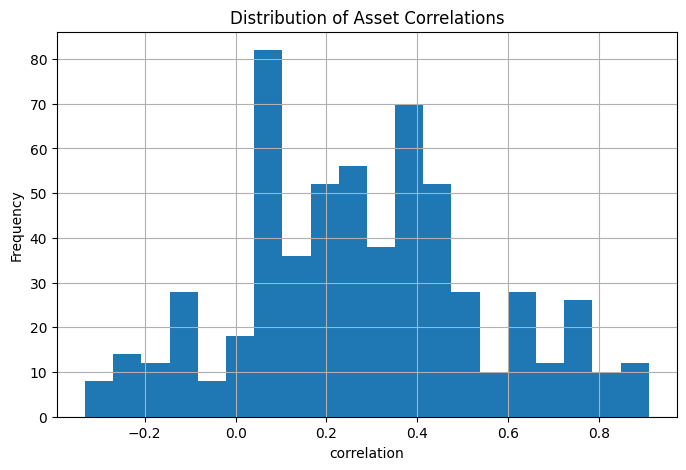

In [34]:
correlation_pairs_df['correlation'].plot(kind='hist', bins=20, title='Distribution of Asset Correlations')
plt.xlabel('correlation')
plt.show()


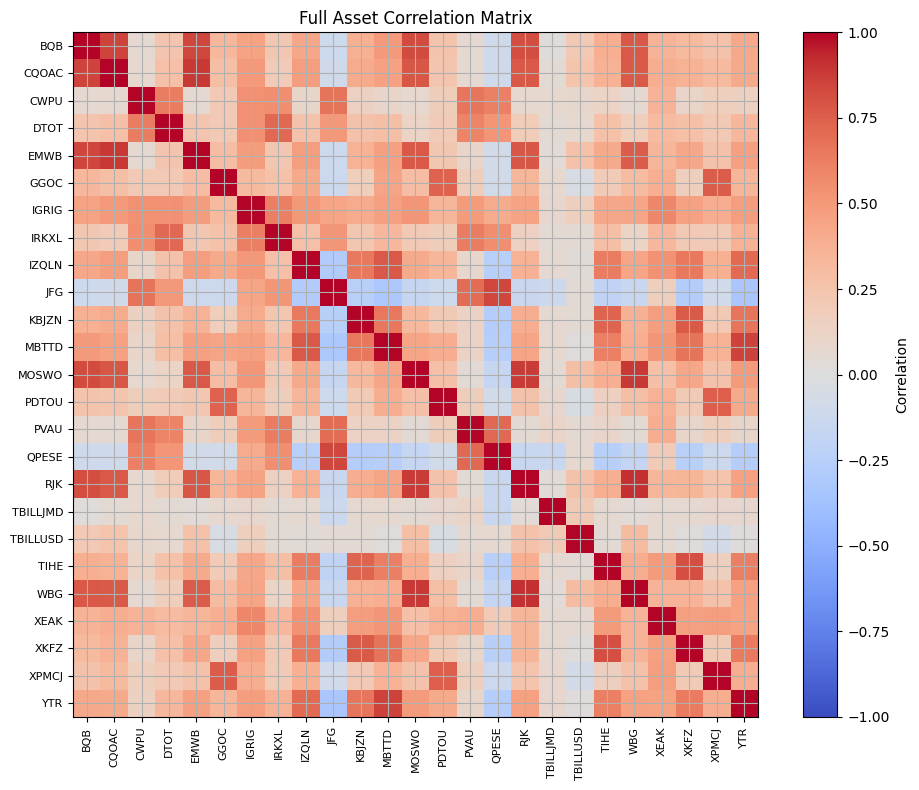

In [35]:
correlation_column_labels = full_asset_correlations_df.columns.astype(str).tolist()
correlation_row_labels = full_asset_correlations_df.index.astype(str).tolist()

plt.figure(figsize=(10, 8))
plt.imshow(full_asset_correlations_df, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='Correlation')
plt.xticks(range(len(correlation_column_labels)), correlation_column_labels, rotation=90, fontsize=8)
plt.yticks(range(len(correlation_row_labels)), correlation_row_labels, fontsize=8)
plt.title('Full Asset Correlation Matrix')
plt.tight_layout()
plt.show()


## Step 11: Analyze `full_asset_covariance_df`

This is the full asset covariance matrix.

How to read it:
- it still compares every asset with every other asset
- unlike correlation, covariance is not standardized to a fixed `-1` to `1` range
- positive values mean same-direction movement around averages
- negative values mean opposite-direction movement around averages
- the diagonal cells are variances
- bigger absolute values can reflect both stronger co-movement and bigger scale in the underlying series

Use the covariance section in Step 6 before interpreting the magnitude of these numbers.


In [36]:
full_asset_covariance_df.shape


(25, 25)

In [37]:
full_asset_covariance_df


,BQB,CQOAC,CWPU,DTOT,EMWB,GGOC,IGRIG,IRKXL,IZQLN,JFG,...,QPESE,RJK,TBILLJMD,TBILLUSD,TIHE,WBG,XEAK,XKFZ,XPMCJ,YTR
BQB,0.042973,0.040515,0.000297,0.005761,0.045394,0.010335,0.012702,0.004037,0.015865,-0.002749,...,-0.001653,0.047268,0.000049,0.000307,0.015192,0.040240,0.013079,0.011571,0.009022,0.019264
CQOAC,0.040515,0.052854,0.000414,0.007454,0.053306,0.010060,0.015485,0.003913,0.019563,-0.002676,...,-0.001884,0.050303,0.000143,0.000401,0.015736,0.044425,0.016205,0.014699,0.012047,0.021020
CWPU,0.000297,0.000414,0.000571,0.001776,0.000431,0.000738,0.001781,0.001147,0.000425,0.001869,...,0.001110,0.000500,0.000023,0.000015,0.000557,0.000410,0.001502,0.000426,0.000628,0.000741
DTOT,0.005761,0.007454,0.001776,0.013806,0.007253,0.003751,0.008654,0.007349,0.005622,0.006947,...,0.004575,0.006162,0.000069,0.000061,0.005974,0.004897,0.006507,0.005614,0.004021,0.008662
EMWB,0.045394,0.053306,0.000431,0.007253,0.068069,0.011699,0.017146,0.005119,0.022269,-0.003625,...,-0.001808,0.057203,0.000103,0.000494,0.020347,0.049836,0.015588,0.019305,0.011366,0.027114
GGOC,0.010335,0.010060,0.000738,0.003751,0.011699,0.022952,0.006512,0.003535,0.011134,-0.002102,...,-0.001013,0.014439,0.000135,-0.000053,0.005487,0.011512,0.010368,0.004321,0.019252,0.011505
IGRIG,0.012702,0.015485,0.001781,0.008654,0.017146,0.006512,0.018605,0.007457,0.012472,0.006923,...,0.004115,0.017097,0.000134,0.000154,0.010939,0.014769,0.014317,0.010826,0.008977,0.014287
IRKXL,0.004037,0.003913,0.001147,0.007349,0.005119,0.003535,0.007457,0.007656,0.004418,0.005200,...,0.003621,0.003573,0.000052,0.000031,0.004732,0.002653,0.005108,0.003134,0.002920,0.007075
IZQLN,0.015865,0.019563,0.000425,0.005622,0.022269,0.011134,0.012472,0.004418,0.032725,-0.005936,...,-0.003459,0.018746,0.000147,0.000033,0.021518,0.019669,0.017171,0.020272,0.011321,0.028554
JFG,-0.002749,-0.002676,0.001869,0.006947,-0.003625,-0.002102,0.006923,0.005200,-0.005936,0.013572,...,0.007379,-0.004539,-0.000172,0.000038,-0.004342,-0.004247,0.003352,-0.005691,-0.001729,-0.008597


In [38]:
full_asset_covariance_df.iloc[:5, :5]


,BQB,CQOAC,CWPU,DTOT,EMWB
BQB,0.042973,0.040515,0.000297,0.005761,0.045394
CQOAC,0.040515,0.052854,0.000414,0.007454,0.053306
CWPU,0.000297,0.000414,0.000571,0.001776,0.000431
DTOT,0.005761,0.007454,0.001776,0.013806,0.007253
EMWB,0.045394,0.053306,0.000431,0.007253,0.068069


In [39]:
full_asset_covariance_df.loc[selected_assets, selected_assets]


,TBILLJMD,TBILLUSD,PVAU,JFG,EMWB
TBILLJMD,0.000151,0.000017,0.000050,-0.000172,0.000103
TBILLUSD,0.000017,0.000050,0.000018,0.000038,0.000494
PVAU,0.000050,0.000018,0.001310,0.002962,0.000961
JFG,-0.000172,0.000038,0.002962,0.013572,-0.003625
EMWB,0.000103,0.000494,0.000961,-0.003625,0.068069


In [40]:
covariance_pairs_df = (
    full_asset_covariance_df.stack()
    .reset_index()
    .rename(columns={'level_0': 'asset_1', 'level_1': 'asset_2', 0: 'covariance'})
)
covariance_pairs_df = covariance_pairs_df[covariance_pairs_df['asset_1'] != covariance_pairs_df['asset_2']]
covariance_pairs_df.head()


,asset_1,asset_2,covariance
1,BQB,CQOAC,0.040515
2,BQB,CWPU,0.000297
3,BQB,DTOT,0.005761
4,BQB,EMWB,0.045394
5,BQB,GGOC,0.010335


### Plots for `full_asset_covariance_df`

The histogram shows the spread of covariance values.
The color plot below is a heatmap-style matrix for the covariance table.


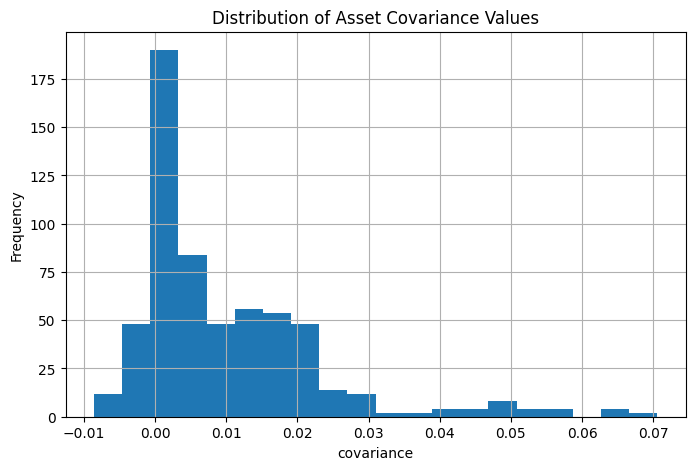

In [41]:
covariance_pairs_df['covariance'].plot(kind='hist', bins=20, title='Distribution of Asset Covariance Values')
plt.xlabel('covariance')
plt.show()


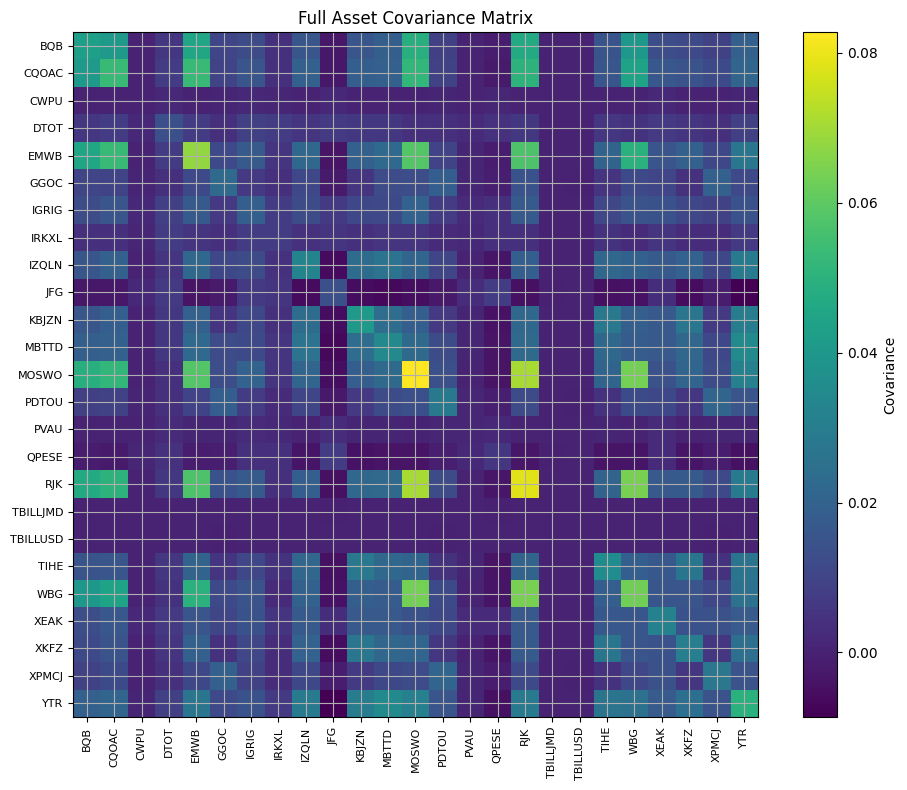

In [42]:
covariance_column_labels = full_asset_covariance_df.columns.astype(str).tolist()
covariance_row_labels = full_asset_covariance_df.index.astype(str).tolist()

plt.figure(figsize=(10, 8))
plt.imshow(full_asset_covariance_df, cmap='viridis')
plt.colorbar(label='Covariance')
plt.xticks(range(len(covariance_column_labels)), covariance_column_labels, rotation=90, fontsize=8)
plt.yticks(range(len(covariance_row_labels)), covariance_row_labels, fontsize=8)
plt.title('Full Asset Covariance Matrix')
plt.tight_layout()
plt.show()


## Step 12: Analyze `full_subclass_correlations_df`

This is the class-level correlation matrix.

Instead of comparing single assets, it compares broader asset subclasses such as bond groups or equity groups.
That makes it useful for spotting broader diversification patterns.
The meaning of the numbers is the same as in the asset correlation matrix.


In [43]:
full_subclass_correlations_df.shape


(12, 12)

In [44]:
full_subclass_correlations_df


,Alternative Investments,Corporate Bonds,Domestic Cyclical Equity,Domestic Defensive Equity,Domestic Financial Equity,Emerging Market Equity,Global Tech Equity,JMD T-Bill,Long Government Bonds,Real Estate Fund,Short Government Bonds,USD T-Bill
Alternative Investments,1.000000,0.572579,0.470956,0.365078,0.413137,0.478318,0.475079,0.096101,0.455911,0.580671,0.522121,0.120401
Corporate Bonds,0.572579,1.000000,0.312903,0.216280,0.264663,0.219385,0.176790,0.056729,0.595406,0.281761,0.571739,0.070533
Domestic Cyclical Equity,0.470956,0.312903,1.000000,0.381631,0.621512,0.468754,0.431190,0.072825,-0.300917,0.515522,0.115247,0.019217
Domestic Defensive Equity,0.365078,0.216280,0.381631,1.000000,0.181865,0.269794,0.281036,0.071570,-0.110785,0.427864,0.177232,-0.060348
Domestic Financial Equity,0.413137,0.264663,0.621512,0.181865,1.000000,0.379400,0.381179,0.062238,-0.264889,0.466803,0.116321,0.029385
Emerging Market Equity,0.478318,0.219385,0.468754,0.269794,0.379400,1.000000,0.779514,0.039980,-0.118015,0.339755,0.079847,0.229985
Global Tech Equity,0.475079,0.176790,0.431190,0.281036,0.381179,0.779514,1.000000,0.041434,-0.170634,0.328244,0.067783,0.279454
JMD T-Bill,0.096101,0.056729,0.072825,0.071570,0.062238,0.039980,0.041434,1.000000,-0.169509,0.078330,0.117291,0.219383
Long Government Bonds,0.455911,0.595406,-0.300917,-0.110785,-0.264889,-0.118015,-0.170634,-0.169509,1.000000,0.170412,0.697044,0.057273
Real Estate Fund,0.580671,0.281761,0.515522,0.427864,0.466803,0.339755,0.328244,0.078330,0.170412,1.000000,0.381237,0.050329


In [45]:
selected_subclasses = [
    'JMD T-Bill',
    'USD T-Bill',
    'Short Government Bonds',
    'Emerging Market Equity',
    'Global Tech Equity',
]
full_subclass_correlations_df.loc[selected_subclasses, selected_subclasses]


,JMD T-Bill,USD T-Bill,Short Government Bonds,Emerging Market Equity,Global Tech Equity
JMD T-Bill,1.000000,0.219383,0.117291,0.039980,0.041434
USD T-Bill,0.219383,1.000000,0.060467,0.229985,0.279454
Short Government Bonds,0.117291,0.060467,1.000000,0.079847,0.067783
Emerging Market Equity,0.039980,0.229985,0.079847,1.000000,0.779514
Global Tech Equity,0.041434,0.279454,0.067783,0.779514,1.000000


In [46]:
subclass_correlation_pairs_df = (
    full_subclass_correlations_df.stack()
    .reset_index()
    .rename(columns={'level_0': 'subclass_1', 'level_1': 'subclass_2', 0: 'correlation'})
)
subclass_correlation_pairs_df = subclass_correlation_pairs_df[
    subclass_correlation_pairs_df['subclass_1'] != subclass_correlation_pairs_df['subclass_2']
]
subclass_correlation_pairs_df.head()


,subclass_1,subclass_2,correlation
1,Alternative Investments,Corporate Bonds,0.572579
2,Alternative Investments,Domestic Cyclical Equity,0.470956
3,Alternative Investments,Domestic Defensive Equity,0.365078
4,Alternative Investments,Domestic Financial Equity,0.413137
5,Alternative Investments,Emerging Market Equity,0.478318


### Plots for `full_subclass_correlations_df`

This heatmap-style plot gives a quicker visual summary of subclass relationships than reading the full table cell by cell.


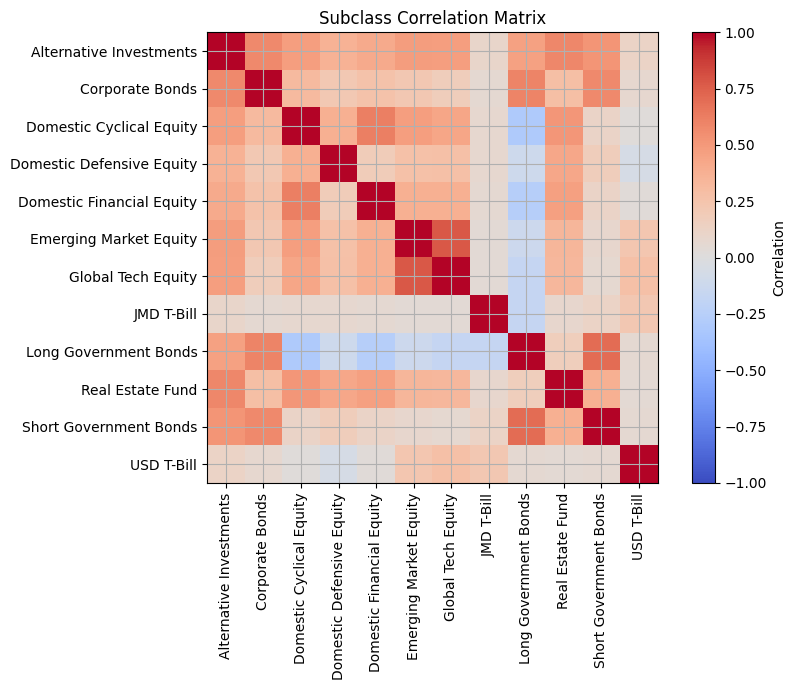

In [47]:
subclass_column_labels = full_subclass_correlations_df.columns.astype(str).tolist()
subclass_row_labels = full_subclass_correlations_df.index.astype(str).tolist()

plt.figure(figsize=(9, 7))
plt.imshow(full_subclass_correlations_df, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='Correlation')
plt.xticks(range(len(subclass_column_labels)), subclass_column_labels, rotation=90)
plt.yticks(range(len(subclass_row_labels)), subclass_row_labels)
plt.title('Subclass Correlation Matrix')
plt.tight_layout()
plt.show()


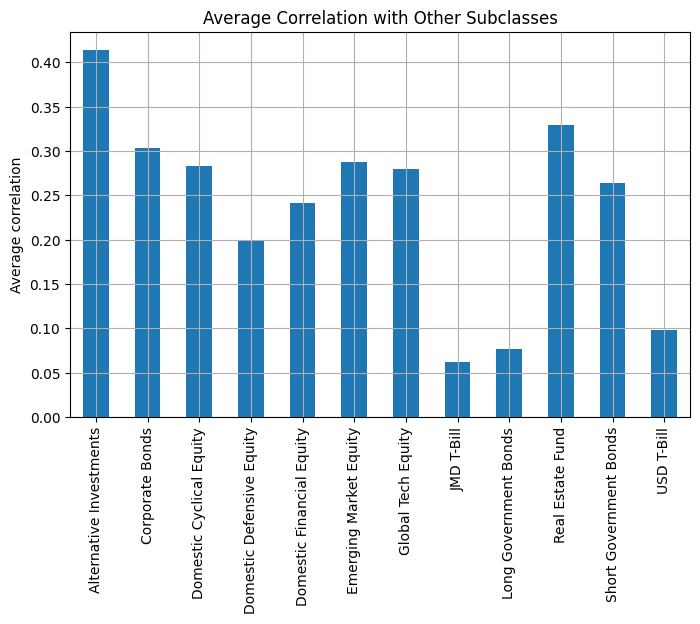

In [48]:
avg_subclass_corr_df = pd.DataFrame({
    'avg_correlation_with_others': (full_subclass_correlations_df.sum(axis=1) - 1) / (len(full_subclass_correlations_df.columns) - 1)
})

avg_subclass_corr_df.plot(kind='bar', legend=False, title='Average Correlation with Other Subclasses')
plt.ylabel('Average correlation')
plt.show()


In [49]:
# Try your own full_subclass_correlations_df analysis below.
# Example ideas:
# full_subclass_correlations_df.loc[['Long Government Bonds'], :]
# subclass_correlation_pairs_df.head()


## Step 13: Next Plot Ideas

If you want, we can later add:
- boxplots
- more focused heatmaps
- bar charts for selected groups


In [50]:
asset_detail = get_asset_detail_frames("PVAU")

asset_detail["asset_df"]



,super_class,asset_class,currency,total_expected_return,income_yield_ann,volatility_ann,semi_deviation_ann,skewness,excess_kurtosis,modified_duration,rate_beta,inflation_beta,fx_beta,expense_ratio_ann
ticker,,,,,,,,,,,,,,
PVAU,Fixed Income,Short Government Bonds,JMD,0.0593,0.0593,0.0362,0.0211,0.0391,0.6842,1.4402,-1.878,-0.4019,0.0,0.0


In [51]:
asset_detail["top_correlations_df"]


,ticker,correlation
0,QPESE,0.714695
1,JFG,0.702427
2,CWPU,0.660427
3,IRKXL,0.628861
4,DTOT,0.601169
5,IGRIG,0.491125
6,XEAK,0.394162
7,GGOC,0.177342
8,PDTOU,0.175621
9,XPMCJ,0.160547


In [52]:
asset_detail["top_covariance_df"]

,ticker,covariance
0,JFG,0.002962
1,DTOT,0.002557
2,XEAK,0.002536
3,IGRIG,0.002425
4,IRKXL,0.001992
5,QPESE,0.001953
6,PDTOU,0.001067
7,GGOC,0.000973
8,XPMCJ,0.000965
9,EMWB,0.000961
